# Hier-COS Current-Run Trade-Off Plots

This notebook reads completed Hier-COS `test_metrics.yaml` files directly from `/scratch/g.saggini1/outputs`.

Included runs:
- equal and `kl_leaf` no-lex baselines;
- coarse-first and fine-first `orthogonalize_all`;
- coarse-first and fine-first `conflict_only` **only when both runs are present for a dataset**.

All plots use the independently selected checkpoint and independent test metrics. FPA and level accuracy are higher-is-better; TICE is lower-is-better.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
LOSS_MODE = 'global_softmax_ce_reg'
SAVE_FIGURES = False
FIGURE_DIR = Path.cwd() / 'generated_figures'

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}
RUN_SPECS = {
    'equal_baseline': ('Equal no-lex', 'baseline_equal', 'baseline'),
    'kl_leaf_baseline': ('kl_leaf no-lex', 'baseline_kl_leaf', 'baseline'),
    'coarse_orthogonalize_all': ('Coarse / ortho-all', 'lex_orthogonalize_all_coarse_first', 'orthogonalize_all'),
    'fine_orthogonalize_all': ('Fine / ortho-all', 'lex_orthogonalize_all_fine_first', 'orthogonalize_all'),
    'coarse_conflict_only': ('Coarse / conflict-only', 'lex_conflict_only_coarse_first', 'conflict_only'),
    'fine_conflict_only': ('Fine / conflict-only', 'lex_conflict_only_fine_first', 'conflict_only'),
}
RUN_COLORS = {
    'equal_baseline': '#777777',
    'kl_leaf_baseline': '#111111',
    'coarse_orthogonalize_all': '#0072B2',
    'fine_orthogonalize_all': '#D55E00',
    'coarse_conflict_only': '#009E73',
    'fine_conflict_only': '#CC79A7',
}
DATASET_COLORS = {'CIFAR-100': '#0072B2', 'CUB-200': '#009E73', 'Aircraft': '#D55E00'}

if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def load_test_metrics(path):
    with Path(path).open('r', encoding='utf-8') as handle:
        return yaml.safe_load(handle)


def discover_rows():
    rows = []
    for dataset_key, dataset_label in DATASETS.items():
        available = {}
        for run_key, (run_label, suffix, rule) in RUN_SPECS.items():
            run_name = f'hiercos_{dataset_key}_{LOSS_MODE}_{suffix}'
            metrics_path = OUTPUTS_ROOT / run_name / 'test_metrics.yaml'
            available[run_key] = metrics_path.exists()

        include_conflict = available['coarse_conflict_only'] and available['fine_conflict_only']
        for run_key, (run_label, suffix, rule) in RUN_SPECS.items():
            if rule == 'conflict_only' and not include_conflict:
                continue
            run_name = f'hiercos_{dataset_key}_{LOSS_MODE}_{suffix}'
            metrics_path = OUTPUTS_ROOT / run_name / 'test_metrics.yaml'
            if not metrics_path.exists():
                if rule != 'conflict_only':
                    print(f'Missing required run: {run_name}')
                continue

            selected = load_test_metrics(metrics_path)['independent']
            metrics = selected['test_metrics']
            row = {
                'dataset': dataset_label,
                'dataset_key': dataset_key,
                'run_key': run_key,
                'run_label': run_label,
                'rule': rule,
                'run_name': run_name,
                'best_epoch': int(selected['best_epoch']),
                'fpa': 100.0 * float(metrics['fpa_independent']),
                'tice': 100.0 * float(metrics['tice_independent']),
            }
            for level in range(3):
                row[f'acc_level_{level}'] = 100.0 * float(metrics[f'acc_level_independent_{level}'])
            rows.append(row)
    return rows


def mark_pareto(rows):
    for dataset in DATASETS.values():
        subset = [row for row in rows if row['dataset'] == dataset]
        for row in subset:
            dominators = [
                other['run_label'] for other in subset if other is not row
                and other['fpa'] >= row['fpa'] and other['tice'] <= row['tice']
                and (other['fpa'] > row['fpa'] or other['tice'] < row['tice'])
            ]
            row['pareto_optimal'] = not dominators
            row['dominated_by'] = dominators
    return rows


def save_or_show(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, bbox_inches='tight')
    plt.show()


rows = mark_pareto(discover_rows())
for dataset in DATASETS.values():
    available = [row['run_label'] for row in rows if row['dataset'] == dataset]
    print(f'{dataset}: {", ".join(available)}')


CIFAR-100: Equal no-lex, kl_leaf no-lex, Coarse / ortho-all, Fine / ortho-all
CUB-200: Equal no-lex, kl_leaf no-lex, Coarse / ortho-all, Fine / ortho-all
Aircraft: Equal no-lex, kl_leaf no-lex, Coarse / ortho-all, Fine / ortho-all


## Priority Trade-Off: FPA vs TICE

Each arrow connects coarse-first to fine-first under the same projection rule. Baselines are shown as reference points.

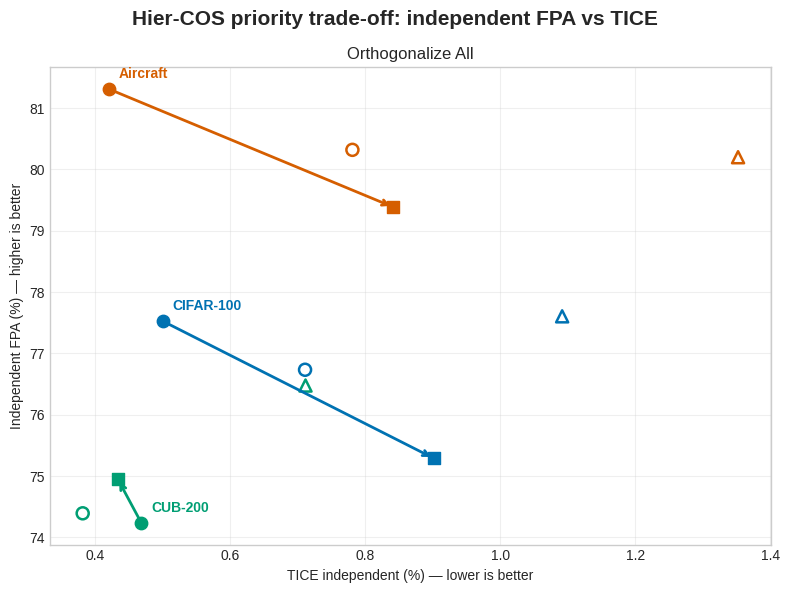

In [3]:
rules = ['orthogonalize_all']
if any(row['rule'] == 'conflict_only' for row in rows):
    rules.append('conflict_only')

fig, axes = plt.subplots(1, len(rules), figsize=(8 * len(rules), 6), squeeze=False, sharey=True)
for ax, rule in zip(axes[0], rules):
    for dataset in DATASETS.values():
        color = DATASET_COLORS[dataset]
        coarse_key = 'coarse_' + rule
        fine_key = 'fine_' + rule
        coarse = next((r for r in rows if r['dataset'] == dataset and r['run_key'] == coarse_key), None)
        fine = next((r for r in rows if r['dataset'] == dataset and r['run_key'] == fine_key), None)
        if coarse and fine:
            ax.annotate('', xy=(fine['tice'], fine['fpa']), xytext=(coarse['tice'], coarse['fpa']),
                        arrowprops={'arrowstyle': '->', 'color': color, 'lw': 2})
            ax.scatter(coarse['tice'], coarse['fpa'], color=color, marker='o', s=80)
            ax.scatter(fine['tice'], fine['fpa'], color=color, marker='s', s=80)
            ax.annotate(dataset, (coarse['tice'], coarse['fpa']), xytext=(7, 8),
                        textcoords='offset points', color=color, fontweight='bold')
        for baseline_key, marker in [('equal_baseline', 'o'), ('kl_leaf_baseline', '^')]:
            baseline = next(r for r in rows if r['dataset'] == dataset and r['run_key'] == baseline_key)
            ax.scatter(baseline['tice'], baseline['fpa'], facecolors='none', edgecolors=color,
                       marker=marker, s=75, linewidths=1.8)
    ax.set_title(rule.replace('_', ' ').title())
    ax.set_xlabel('TICE independent (%) — lower is better')
    ax.grid(True, alpha=0.3)
axes[0, 0].set_ylabel('Independent FPA (%) — higher is better')
fig.suptitle('Hier-COS priority trade-off: independent FPA vs TICE', fontsize=15, fontweight='bold')
fig.tight_layout()
save_or_show(fig, 'fpa_tice_priority_tradeoff.svg')


## Level-Accuracy Changes Relative to Equal No-Lex

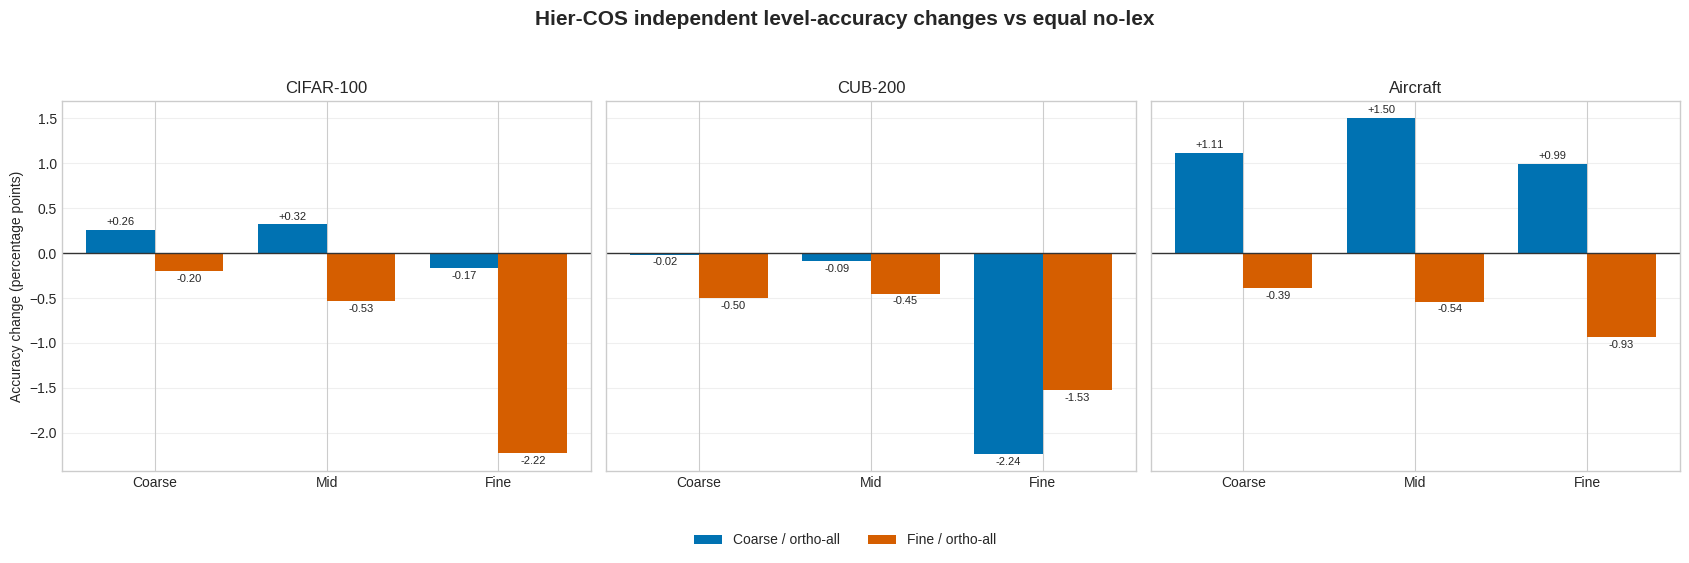

In [7]:
comparison_keys = ['coarse_orthogonalize_all', 'fine_orthogonalize_all']
if any(row['run_key'] == 'coarse_conflict_only' for row in rows):
    comparison_keys += ['coarse_conflict_only', 'fine_conflict_only']

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)
level_labels = ['Coarse', 'Mid', 'Fine']
x = np.arange(3)
width = 0.8 / len(comparison_keys)
for ax, dataset in zip(axes, DATASETS.values()):
    baseline = next(r for r in rows if r['dataset'] == dataset and r['run_key'] == 'kl_leaf_baseline')
    for index, run_key in enumerate(comparison_keys):
        run = next((r for r in rows if r['dataset'] == dataset and r['run_key'] == run_key), None)
        if run is None:
            continue
        deltas = [run[f'acc_level_{level}'] - baseline[f'acc_level_{level}'] for level in range(3)]
        positions = x - 0.4 + width / 2 + index * width
        bars = ax.bar(positions, deltas, width, label=run['run_label'], color=RUN_COLORS[run_key])
        ax.bar_label(bars, fmt='%+.2f', fontsize=8, padding=2)
    ax.axhline(0, color='#333333', linewidth=1)
    ax.set_title(dataset)
    ax.set_xticks(x, level_labels)
    ax.grid(True, axis='y', alpha=0.3)
axes[0].set_ylabel('Accuracy change (percentage points)')
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=min(4, len(labels)), bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Hier-COS independent level-accuracy changes vs equal no-lex', fontsize=15, fontweight='bold')
fig.tight_layout(rect=(0, 0.08, 1, 0.94))
save_or_show(fig, 'level_accuracy_deltas.svg')


## FPA–TICE Pareto Frontiers

A point is Pareto-optimal when no available run has both higher-or-equal FPA and lower-or-equal TICE, with at least one strict improvement.

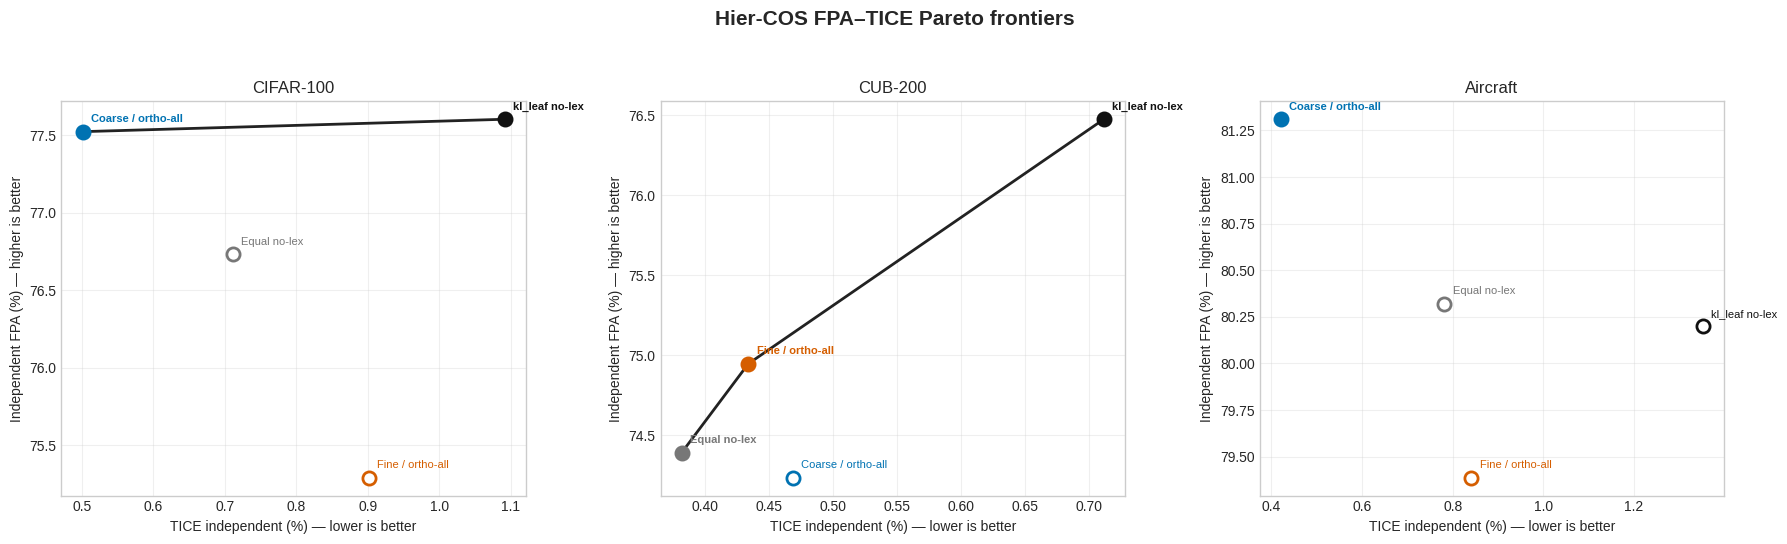

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, dataset in zip(axes, DATASETS.values()):
    subset = [row for row in rows if row['dataset'] == dataset]
    frontier = sorted((row for row in subset if row['pareto_optimal']), key=lambda row: row['tice'])
    if len(frontier) > 1:
        ax.plot([r['tice'] for r in frontier], [r['fpa'] for r in frontier], color='#222222', linewidth=2)
    for row in subset:
        color = RUN_COLORS[row['run_key']]
        ax.scatter(row['tice'], row['fpa'], s=90, edgecolor=color,
                   facecolor=color if row['pareto_optimal'] else 'white', linewidth=2, zorder=3)
        ax.annotate(row['run_label'], (row['tice'], row['fpa']), xytext=(6, 7),
                    textcoords='offset points', fontsize=8,
                    fontweight='bold' if row['pareto_optimal'] else 'normal', color=color)
    ax.set_title(dataset)
    ax.set_xlabel('TICE independent (%) — lower is better')
    ax.set_ylabel('Independent FPA (%) — higher is better')
    ax.grid(True, alpha=0.3)
fig.suptitle('Hier-COS FPA–TICE Pareto frontiers', fontsize=15, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_or_show(fig, 'fpa_tice_pareto_frontiers.svg')


## Pareto Summary

In [6]:
for dataset in DATASETS.values():
    print(f'\n{dataset}')
    for row in [r for r in rows if r['dataset'] == dataset]:
        status = 'Pareto-optimal' if row['pareto_optimal'] else 'dominated by ' + ', '.join(row['dominated_by'])
        print(f"  {row['run_label']:<23} FPA={row['fpa']:.2f}%  TICE={row['tice']:.2f}%  {status}")



CIFAR-100
  Equal no-lex            FPA=76.73%  TICE=0.71%  dominated by Coarse / ortho-all
  kl_leaf no-lex          FPA=77.60%  TICE=1.09%  Pareto-optimal
  Coarse / ortho-all      FPA=77.52%  TICE=0.50%  Pareto-optimal
  Fine / ortho-all        FPA=75.29%  TICE=0.90%  dominated by Equal no-lex, Coarse / ortho-all

CUB-200
  Equal no-lex            FPA=74.39%  TICE=0.38%  Pareto-optimal
  kl_leaf no-lex          FPA=76.48%  TICE=0.71%  Pareto-optimal
  Coarse / ortho-all      FPA=74.24%  TICE=0.47%  dominated by Equal no-lex, Fine / ortho-all
  Fine / ortho-all        FPA=74.95%  TICE=0.43%  Pareto-optimal

Aircraft
  Equal no-lex            FPA=80.32%  TICE=0.78%  dominated by Coarse / ortho-all
  kl_leaf no-lex          FPA=80.20%  TICE=1.35%  dominated by Equal no-lex, Coarse / ortho-all
  Coarse / ortho-all      FPA=81.31%  TICE=0.42%  Pareto-optimal
  Fine / ortho-all        FPA=79.39%  TICE=0.84%  dominated by Equal no-lex, Coarse / ortho-all
